# General Editing Efficiency Analysis

Sensor editing percentage.  

Kexin Dong

Dec 5, 2025

In [1]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA
import seaborn as sns

# Venn plot showing the guides overlapping of the OG and validation library, subpooled by ABE and CBE

(targeting guides only)

In [256]:
CBE.columns

Index(['Unnamed: 0', 'gRNA_id', 'mutation_idx', 'gene_name_h', 'gene_id_h',
       'tx_id_h', 'chr_h', 'exon_num_h', 'strand_h', 'match', 'start_h',
       'end_h', 'ref_seq_h', 'alt_seq_h', 'HGVSc_h', 'HGVSp_h',
       'classification_h', 'exon_h', 'type_h', 'status', 'error', 'statement',
       'gene_name_m', 'gene_id_m', 'tx_id_m', 'chr_m', 'exon_num_m',
       'strand_m', 'type_m', 'classification_m', 'exon_m', 'start_m', 'end_m',
       'ref_seq_m', 'alt_seq_m', 'HGVSc_m', 'HGVSp_m', 'PAM', 'PAM_strand',
       'Protospacer_30', 'Protospacer', 'Protospacer_Location',
       'Ideal_Edit_Window', 'Editor', 'OnTarget_Azimuth_Score', 'sensor_wt',
       'sensor_alt', 'sensor_orientation', 'sensor_error',
       'contains_polyT_terminator', 'contains_RE_site', 'num_potential_vars',
       'classification', 'Genome_version', 'Hamming_BC', 'Pool', 'gRNA_oligo',
       'gene_name_m_corrected', 'legacy', 'newly_added', 'level_0', 'PAM_NGN'],
      dtype='object')

In [258]:
LIB = pd.read_csv('FINAL_focused_library_PAM.csv')
ABE = LIB[(LIB['Editor']=='ABE') & (LIB['classification']=='targeting guide')]
#CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['legacy']==False) & (MBES['classification']=='targeting guide')]
CBE = LIB[(LIB['Editor']=='CBE') & (LIB['classification'].isin(['targeting guide','essential truncation guide']))]
CBE_NGG = CBE[CBE['PAM_NGN'].isin([f'{x}GG' for x in ['A','T','C','G']])]
print(len(CBE),len(CBE_NGG))

897 261


In [260]:
LIB_OG = pd.read_csv('MBESv2_corrected.csv')
ABE_OG = LIB_OG[(LIB_OG['Editor']=='ABE') & (LIB_OG['classification']=='targeting guide')]
#CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['legacy']==False) & (MBES['classification']=='targeting guide')]
CBE_OG = LIB_OG[(LIB_OG['Editor']=='CBE') & (LIB_OG['classification']=='targeting guide')]

In [4]:
len(ABE)

170

In [5]:
len(ABE_OG)

1034

In [6]:
len(CBE)

897

In [7]:
len(CBE_OG)

12806

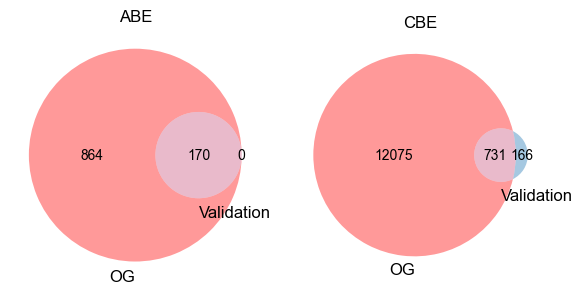

In [8]:
fig, ax = plt.subplots(1,2,figsize = (6,3))
list1 = ABE_OG['gRNA_id']
list2 = ABE['gRNA_id']
venn2([set(list1), set(list2)], set_labels=('OG', 'Validation'), set_colors=("red", "tab:blue"), ax=ax[0])
ax[0].set_title('ABE')
list1 = CBE_OG['gRNA_id']
list2 = CBE['gRNA_id']
venn2([set(list1), set(list2)], set_labels=('OG', 'Validation'), set_colors=("red", "tab:blue"), ax=ax[1])
ax[1].set_title('CBE')
plt.savefig('figures/venn_validation_og_guides.pdf')
fig.tight_layout()

# Average editing percentage for each sample. (showing targeting guide only)

OG: figure 2e 



In [261]:
fp = '/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/crispresso_data/compact_lane_merged_unfiltered'
ABE_BC_RAW = sorted(os.listdir(f'{fp}/ABE_BC'))
ABE_EPO_RAW = sorted(os.listdir(f'{fp}/ABE_EPO'))
CBE_BC_RAW = sorted(os.listdir(f'{fp}/CBE_BC'))
CBE_EPO_RAW = sorted(os.listdir(f'{fp}/CBE_EPO'))

#set filters for minimum number of sensor reads
min_sensor_reads = 100
name_dict = {'men':'Meninges', 'spleen':'Spleen', 'bm':'Bone Marrow', 'd5':'D5', 'd15':'D15', 'lib':'Plasmid', 'input':'Input (D0)'}

In [262]:
ABE_BC_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'd15-rep4_compact_unfiltered.csv',
 'd15-rep5_compact_unfiltered.csv',
 'd5_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'lib_compact_unfiltered.csv',
 'men1_compact_unfiltered.csv',
 'men2_compact_unfiltered.csv',
 'men3_compact_unfiltered.csv',
 'men4_compact_unfiltered.csv',
 'men5_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [263]:
t = []
corr = []
name = []

for i in ABE_BC_RAW:
    g = pd.read_csv(f'{fp}/ABE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    #print(len(g))
    g2 = pd.merge(g, ABE, on='gRNA_id')
    #print(len(g2))
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

list_samples = ['bm']*5+['d15']*5+['d5','input','lib']+['men']*5+['spleen']*5

In [264]:
name = [name_dict[x] for x in list_samples]
ABE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_BC_EDITING = pd.concat((ABE_BC_editing1, ABE_BC_editing2))

In [265]:
ABE_EPO_RAW

['bm1_compact_unfiltered.csv',
 'bm2_compact_unfiltered.csv',
 'bm3_compact_unfiltered.csv',
 'bm4_compact_unfiltered.csv',
 'bm5_compact_unfiltered.csv',
 'd15-rep1_compact_unfiltered.csv',
 'd15-rep2_compact_unfiltered.csv',
 'd15-rep3_compact_unfiltered.csv',
 'd15-rep4_compact_unfiltered.csv',
 'd15-rep5_compact_unfiltered.csv',
 'd5_compact_unfiltered.csv',
 'input_compact_unfiltered.csv',
 'lib_compact_unfiltered.csv',
 'men1_compact_unfiltered.csv',
 'men2_compact_unfiltered.csv',
 'men3_compact_unfiltered.csv',
 'men4_compact_unfiltered.csv',
 'men5_compact_unfiltered.csv',
 'spleen1_compact_unfiltered.csv',
 'spleen2_compact_unfiltered.csv',
 'spleen3_compact_unfiltered.csv',
 'spleen4_compact_unfiltered.csv',
 'spleen5_compact_unfiltered.csv']

In [ ]:
i = 'input_compact_unfiltered.csv'
g = pd.read_csv(f'{fp}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})

In [268]:
g

,gRNA_id,Reads_in_input,Reads_lowqual,Reads_aligned_all_amplicons,Reads_aligned_WT,Reads_aligned_HDR,Reads_unaligned,WT,correct_edit,target_base_edit,...,byproduct_INDEL,byproduct_sub,byproduct_ambiguous,corr_perc,target_base_edit_perc,WT_perc,byproduct_all_perc,byproduct_INDEL_perc,byproduct_sub_perc,byproduct_ambiguous_perc
0,gRNA_1000,11103,0,11103,11079,13,11,8412,1,13,...,0,2679,11,0.009007,0.117085,75.763307,24.227686,0.000000,24.128614,0.099072
1,gRNA_1004,0,0,0,0,0,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,gRNA_10049,6566,14,6552,6500,47,5,4777,1,47,...,0,1684,90,0.015263,0.717338,72.909035,27.075702,0.000000,25.702076,1.373626
3,gRNA_1006,0,0,0,0,0,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,gRNA_10106,1475,285,1190,1157,33,0,901,2,33,...,0,287,0,0.168067,2.773109,75.714286,24.117647,0.000000,24.117647,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,gRNA_9736,0,0,0,0,0,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1629,gRNA_9742,0,0,0,0,0,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1630,gRNA_9745,14547,0,14547,14445,49,53,13174,9,49,...,3,1290,71,0.061868,0.336839,90.561628,9.376504,0.020623,8.867808,0.488073
1631,gRNA_990,0,0,0,0,0,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [269]:
g2 = pd.merge(g, ABE, on='gRNA_id')

In [270]:
t = []
corr = []
name = []

for i in ABE_EPO_RAW:
    print(i)
    g = pd.read_csv(f'{fp}/ABE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))

list_samples = ['bm']*5+['d15']*5+['d5','input','lib']+['men']*5+['spleen']*5

name = [name_dict[x] for x in list_samples]
ABE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_EPO_EDITING = pd.concat((ABE_EPO_editing1, ABE_EPO_editing2))

bm1_compact_unfiltered.csv
bm2_compact_unfiltered.csv
bm3_compact_unfiltered.csv
bm4_compact_unfiltered.csv
bm5_compact_unfiltered.csv
d15-rep1_compact_unfiltered.csv
d15-rep2_compact_unfiltered.csv
d15-rep3_compact_unfiltered.csv
d15-rep4_compact_unfiltered.csv
d15-rep5_compact_unfiltered.csv
d5_compact_unfiltered.csv
input_compact_unfiltered.csv
lib_compact_unfiltered.csv
men1_compact_unfiltered.csv
men2_compact_unfiltered.csv
men3_compact_unfiltered.csv
men4_compact_unfiltered.csv
men5_compact_unfiltered.csv
spleen1_compact_unfiltered.csv
spleen2_compact_unfiltered.csv
spleen3_compact_unfiltered.csv
spleen4_compact_unfiltered.csv
spleen5_compact_unfiltered.csv


In [271]:
ABE_EPO_EDITING

,Sample,Editing %,Edit Type
0,Bone Marrow,84.267874,Target Editing (w/ Bystanders)
1,Bone Marrow,81.777630,Target Editing (w/ Bystanders)
2,Bone Marrow,79.392622,Target Editing (w/ Bystanders)
3,Bone Marrow,81.464935,Target Editing (w/ Bystanders)
4,Bone Marrow,85.275510,Target Editing (w/ Bystanders)
5,D15,81.859461,Target Editing (w/ Bystanders)
6,D15,83.632498,Target Editing (w/ Bystanders)
7,D15,84.709774,Target Editing (w/ Bystanders)
8,D15,83.194145,Target Editing (w/ Bystanders)
9,D15,81.773336,Target Editing (w/ Bystanders)


In [272]:
t = []
corr = []
name = []

for i in CBE_BC_RAW:
    g = pd.read_csv(f'{fp}/CBE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
list_samples = ['bm']*3+['d15']*5+['d5']*5+['input']*5+['lib']+['men']*3+['spleen']*3

name = [name_dict[x] for x in list_samples]
CBE_BC_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
CBE_BC_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
CBE_BC_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_BC_editing2['Edit Type'] = 'Pure Correct Editing'
CBE_BC_EDITING = pd.concat((CBE_BC_editing1, CBE_BC_editing2))

In [274]:
t = []
corr = []
name = []

for i in CBE_BC_RAW:
    g = pd.read_csv(f'{fp}/CBE_BC/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE_NGG, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
list_samples = ['bm']*3+['d15']*5+['d5']*5+['input']*5+['lib']+['men']*3+['spleen']*3

name = [name_dict[x] for x in list_samples]
CBE_BC_editing1_NGG = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
CBE_BC_editing2_NGG = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
CBE_BC_editing1_NGG['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_BC_editing2_NGG['Edit Type'] = 'Pure Correct Editing'
CBE_BC_EDITING_NGG = pd.concat((CBE_BC_editing1_NGG, CBE_BC_editing2_NGG))

In [277]:
t = []
corr = []
name = []

for i in CBE_EPO_RAW:
    g = pd.read_csv(f'{fp}/CBE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
list_samples = ['bm']*5+['d15']*5+['d5']*5+['input']*5+['lib']+['men']*5+['spleen']*5

name = [name_dict[x] for x in list_samples]
CBE_EPO_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
CBE_EPO_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
CBE_EPO_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_EPO_editing2['Edit Type'] = 'Pure Correct Editing'
CBE_EPO_EDITING = pd.concat((CBE_EPO_editing1, CBE_EPO_editing2))

In [278]:
t = []
corr = []
name = []

for i in CBE_EPO_RAW:
    g = pd.read_csv(f'{fp}/CBE_EPO/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE_NGG, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
list_samples = ['bm']*5+['d15']*5+['d5']*5+['input']*5+['lib']+['men']*5+['spleen']*5

name = [name_dict[x] for x in list_samples]
CBE_EPO_editing1_NGG = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
CBE_EPO_editing2_NGG = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
CBE_EPO_editing1_NGG['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_EPO_editing2_NGG['Edit Type'] = 'Pure Correct Editing'
CBE_EPO_EDITING_NGG = pd.concat((CBE_EPO_editing1_NGG, CBE_EPO_editing2_NGG))

In [23]:
CBE_EPO_EDITING['Sample'].unique()

array(['Bone Marrow', 'D15', 'D5', 'Input (D0)', 'Plasmid', 'Meninges',
       'Spleen'], dtype=object)

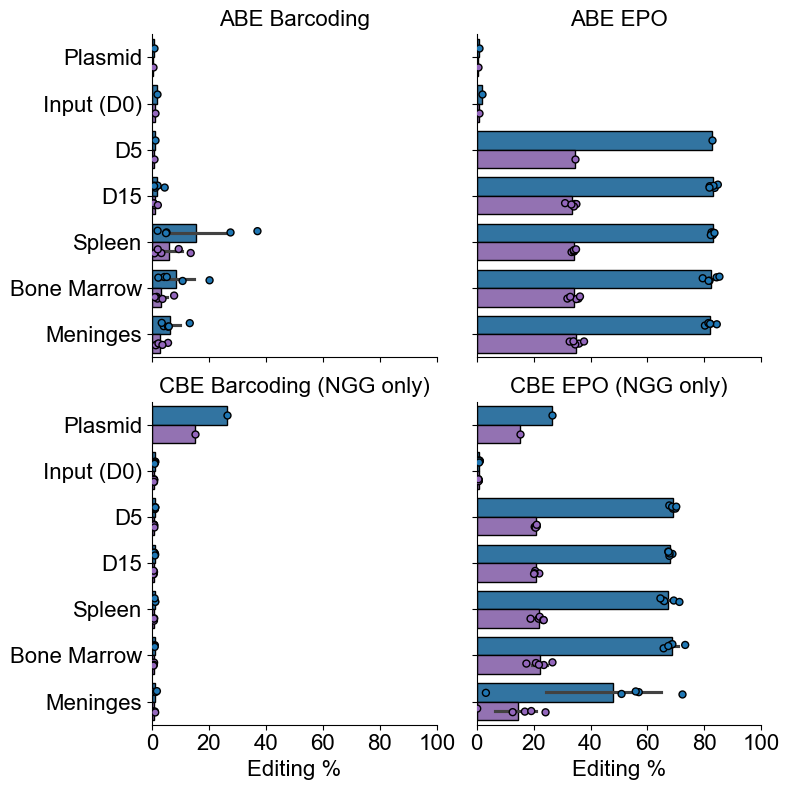

In [279]:
fig, ax = plt.subplots(2,2, figsize=(8,8), sharey=True, sharex=True)
order = ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

sns.barplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order)
sns.barplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order)
sns.barplot(data = CBE_BC_EDITING_NGG, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order)
sns.barplot(data = CBE_EPO_EDITING_NGG, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order)

sns.stripplot(data = ABE_BC_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order, dodge=True, s=5)
sns.stripplot(data = ABE_EPO_EDITING, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0][1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order, dodge=True, s=5)
sns.stripplot(data = CBE_BC_EDITING_NGG, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order, dodge=True, s=5)
sns.stripplot(data = CBE_EPO_EDITING_NGG, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1][1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order, dodge=True, s=5)

ax[0][0].legend([],[], frameon=False)
ax[0][1].legend([],[], frameon=False)
ax[1][0].legend([],[], frameon=False)
ax[1][1].legend([],[], frameon=False)

ax[0][0].set_ylabel('')
ax[1][0].set_ylabel('')
ax[0][0].set_xticks([0,20,40,60,80,100])

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)


ax[0][0].set_title('ABE Barcoding', fontsize = 16)
ax[0][1].set_title('ABE EPO', fontsize = 16)
ax[1][0].set_title('CBE Barcoding (NGG only)', fontsize = 16)
ax[1][1].set_title('CBE EPO (NGG only)', fontsize = 16)

ax[1][0].set_xlabel('Editing %', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)

ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)
fig.tight_layout()
fig.savefig('figures/avg_editing_NGG.pdf')

# Pearson coorelation of Target and Perfect Editing

In [25]:
# load in MLE files

fp = '/Users/kexindong/Documents/GitHub/PhD-FSR-MH-Lab/07_B-ALL_resubmission_20250819/validation_screen_analysis/MLE'
name_list = ['ABE_BC', 'ABE_EPO', 'CBE_BC', 'CBE_EPO']

# Dictionary to store everything
MLE = {}

for name in name_list:
    folder = os.path.join(fp, name)
    loaded_dict = {}
    
    # Loop through all CSV files inside the folder
    for filename in os.listdir(folder):
        if filename.endswith('.csv'):
            sample_name = filename.replace('.csv', '')
            file_path = os.path.join(folder, filename)
            
            df = pd.read_csv(file_path)  # Read CSV
            loaded_dict[sample_name] = df  # Store in dictionary
    
    MLE[name] = loaded_dict

In [26]:
MLE['ABE_EPO'].keys()

dict_keys(['input', 'd15', 'd5', 'lib', 'spleen', 'men', 'bm'])

In [41]:
#need to update and filter for sensor counts

read_cutoff = 10

d1 = dict(zip(list(MLE['ABE_EPO'].keys()), ['INPUT', 'D15', 'D5','PLASMID', 'S', 'M', 'BM']))

new_cols = []
reads = []
read_names = []
for i in MLE['CBE_EPO'].keys():
    a = MLE['CBE_EPO'][i]
    aa = pd.merge(CBE, a, right_on ='Guide_ID', left_on = 'gRNA_id')
    new_cols.append(aa['target_base_edit_perc'])
    reads.append(aa['Reads_aligned_all_amplicons'])
    read_names.append(f'reads_{i}')

names22 = [d1[i] for i in list(MLE['CBE_EPO'].keys())]
CBE_editing = pd.DataFrame(dict(zip(names22, new_cols)))

CBE_reads = pd.DataFrame(dict(zip(read_names, reads)))
CBE_editing_combined = pd.concat([CBE_editing, CBE_reads], axis=1)
CBE_editing_filtered = CBE_editing_combined[(CBE_editing_combined['reads_input']>=read_cutoff) & (CBE_editing_combined['reads_spleen']>=read_cutoff) & (CBE_editing_combined['reads_men']>=read_cutoff) & (CBE_editing_combined['reads_lib']>=read_cutoff) & (CBE_editing_combined['reads_bm']>=read_cutoff) & (CBE_editing_combined['reads_d5']>=read_cutoff) &(CBE_editing_combined['reads_d15']>=read_cutoff)]
CBE_editing_filtered

,INPUT,D15,D5,PLASMID,S,M,BM,reads_input,reads_d15,reads_d5,reads_lib,reads_spleen,reads_men,reads_bm
1,0.028966,69.971205,82.337567,61.538462,97.767366,27.519380,97.400191,10357,2431,19131,13,24545,516,32387
3,0.085157,60.849240,69.809634,5.000000,37.896847,12.500000,9.957219,30532,5134,22378,20,18458,16,21271
6,0.084918,0.257069,0.009327,0.000000,0.061867,0.000000,0.050042,11776,1556,10722,75,25862,60,31973
16,0.911795,91.179474,88.850049,47.368421,70.470035,67.813142,55.515419,25554,7834,33471,19,51209,3896,14949
18,0.015676,0.027601,0.007846,0.000000,0.013235,0.000000,0.009681,19138,3623,12745,12,15111,1256,30987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,0.008466,0.000000,0.003383,0.000000,0.009109,0.000000,0.020986,35435,7338,29556,14,76847,4641,23825
883,0.015551,0.007433,0.013250,0.000000,0.014469,0.000000,0.008591,38582,13453,30189,15,27646,4365,34919
892,0.016522,83.209092,75.278836,6.666667,81.152268,32.181639,65.245821,36315,8183,28870,15,19249,1013,16211
893,0.009909,0.000000,0.012314,0.000000,0.000000,0.000000,0.000000,30275,8054,24362,12,19819,723,792


In [42]:

new_cols = []
reads = []
read_names = []
for i in MLE['ABE_EPO'].keys():
    a = MLE['ABE_EPO'][i]
    aa = pd.merge(ABE, a, right_on ='Guide_ID', left_on = 'gRNA_id')
    new_cols.append(a['target_base_edit_perc'])
    reads.append(a['Reads_aligned_all_amplicons'])
    read_names.append(f'reads_{i}')

names22 = [d1[i] for i in list(MLE['ABE_EPO'].keys())]
ABE_editing = pd.DataFrame(dict(zip(names22, new_cols)))
ABE_reads = pd.DataFrame(dict(zip(read_names, reads)))

ABE_editing_combined = pd.concat([ABE_editing, ABE_reads], axis=1)

ABE_editing_filtered = ABE_editing_combined[(ABE_editing_combined['reads_input']>=read_cutoff) & (ABE_editing_combined['reads_spleen']>=read_cutoff) & (ABE_editing_combined['reads_men']>=read_cutoff) & (ABE_editing_combined['reads_lib']>=read_cutoff) & (ABE_editing_combined['reads_bm']>=read_cutoff) & (ABE_editing_combined['reads_d5']>=read_cutoff) &(ABE_editing_combined['reads_d15']>=read_cutoff)]
ABE_editing_filtered

,INPUT,D15,D5,PLASMID,S,M,BM,reads_input,reads_d15,reads_d5,reads_lib,reads_spleen,reads_men,reads_bm
0,0.117085,33.818976,47.272146,0.007619,38.847308,35.811753,38.123628,11103,157592,28154,13125,82971,27262,75145
2,0.717338,77.317541,76.524193,0.087831,74.883544,93.308588,90.038325,6552,187850,46418,12524,157570,145754,253883
4,2.773109,89.285423,96.333297,0.031636,96.953999,96.862402,98.361754,1190,98072,27627,3161,104432,31999,94003
5,0.298913,71.463523,60.198376,0.056872,78.280012,96.293448,54.699292,3680,58448,15022,5275,65640,48104,56317
13,0.595238,98.410266,91.028972,0.024062,97.853195,98.272373,98.073755,1848,87436,15394,4156,60788,46943,53420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,0.409370,97.106952,92.124195,0.018975,91.908098,97.404203,94.414268,4397,29761,10564,5270,15843,10517,23381
1616,0.396136,80.694424,68.057092,0.009682,75.286385,93.086633,75.870897,18428,154603,36152,20657,129022,91663,179671
1617,1.281337,98.317064,97.564225,0.156740,99.387243,99.759980,98.228667,1795,92814,10510,3190,50591,7916,50414
1618,1.424870,78.450114,69.627201,0.000000,81.184039,95.832759,86.154940,772,54404,13117,2316,27668,65271,21105


[Text(1, 0.5, 'INPUT'),
 Text(1, 1.5, 'M'),
 Text(1, 2.5, 'PLASMID'),
 Text(1, 3.5, 'D15'),
 Text(1, 4.5, 'D5'),
 Text(1, 5.5, 'S'),
 Text(1, 6.5, 'BM')]

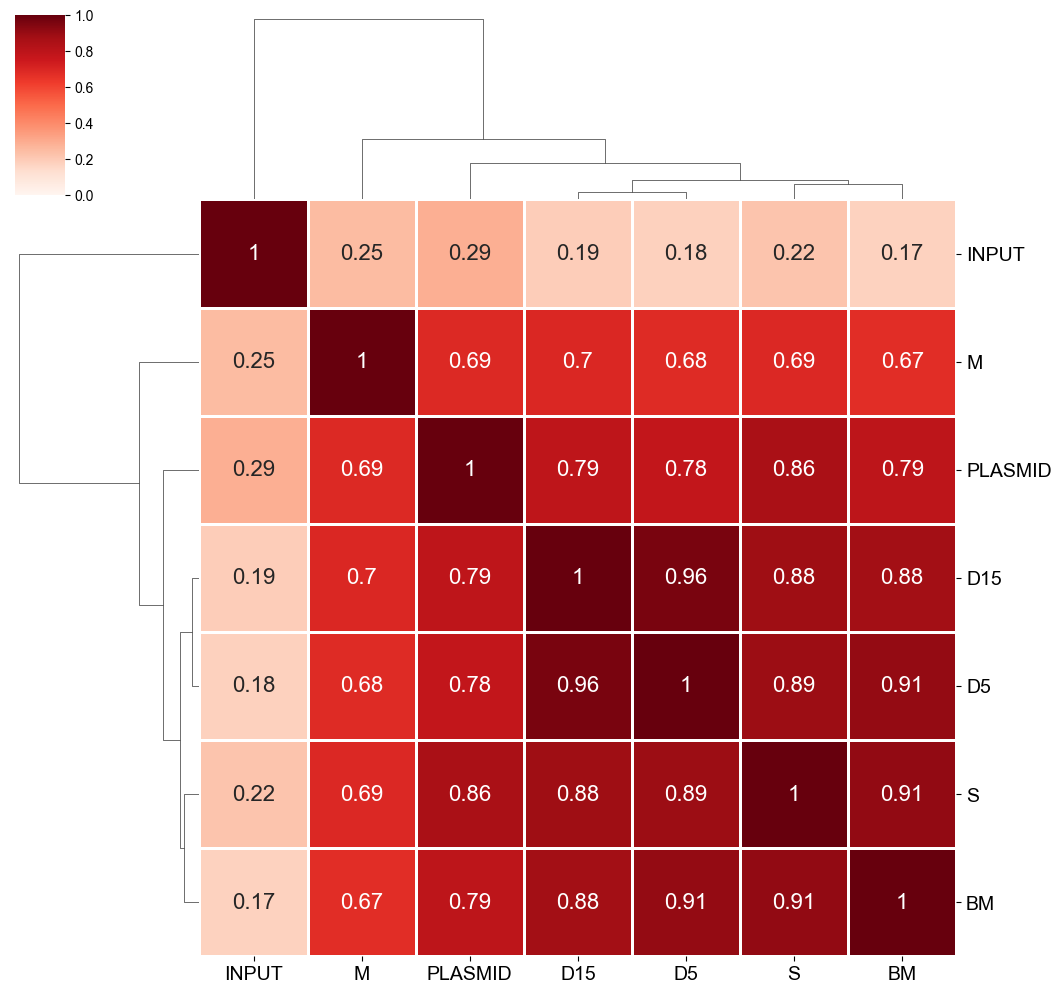

In [43]:
g = sns.clustermap(CBE_editing_filtered[names22].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/CBE_editing_heatmap.pdf')

[Text(1, 0.5, 'M'),
 Text(1, 1.5, 'BM'),
 Text(1, 2.5, 'S'),
 Text(1, 3.5, 'D15'),
 Text(1, 4.5, 'D5'),
 Text(1, 5.5, 'INPUT'),
 Text(1, 6.5, 'PLASMID')]

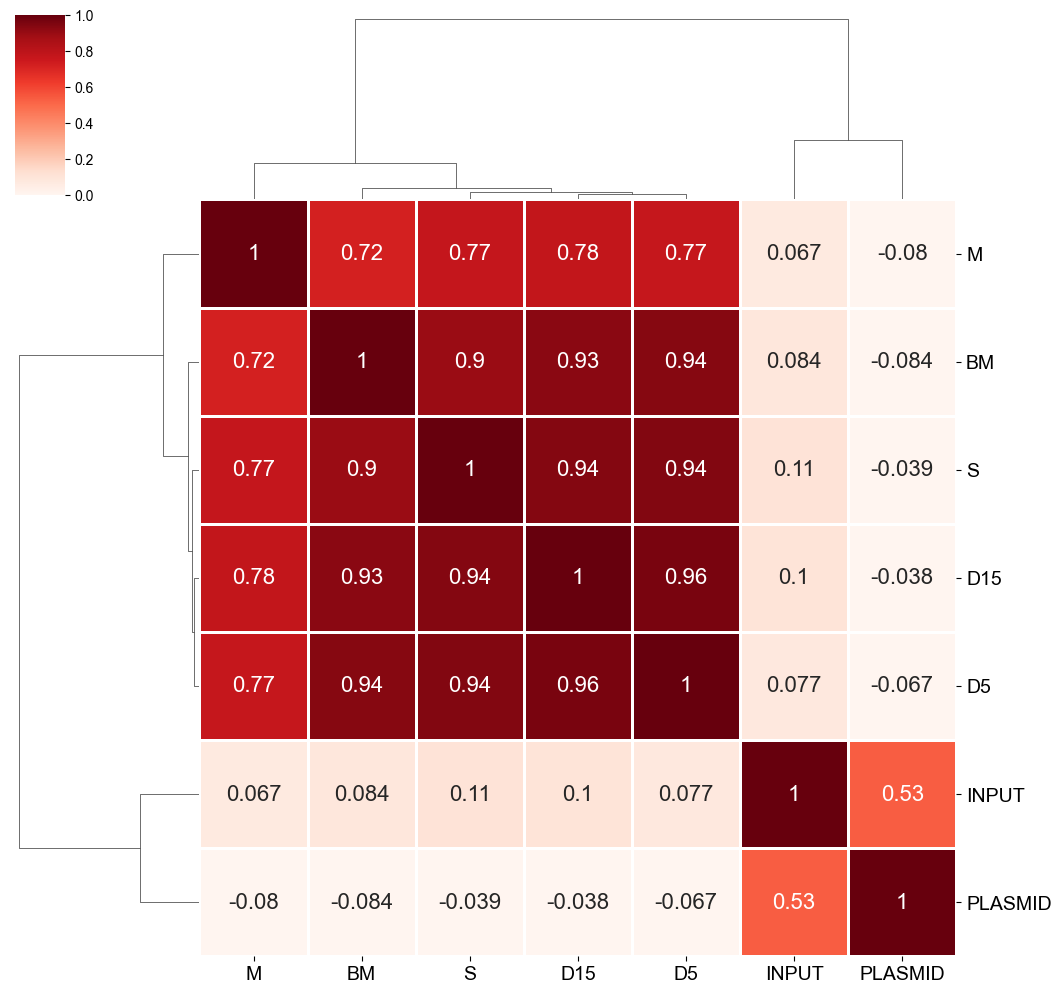

In [44]:
g = sns.clustermap(ABE_editing_filtered[names22].corr(method='pearson'), cmap='Reds', vmin=0, annot=True, linewidth=1, annot_kws={"size": 16})

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 14, rotation=0)
#g.savefig('figures/ABE_editing_heatmap.pdf')

# CDF (Cumulative Distribution Function) of target editing and perfect editing
OG: extended figure 5b

In [31]:
def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

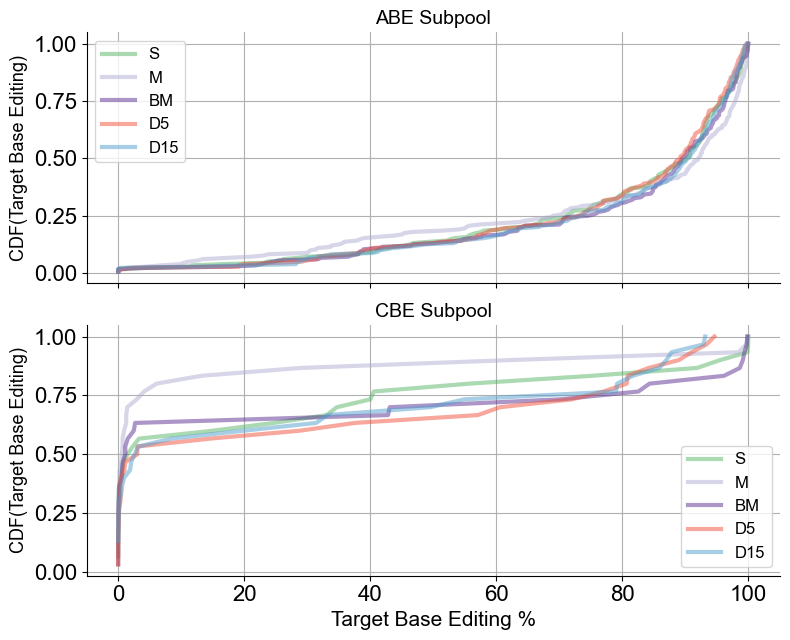

In [32]:
cs = ["#f47824", "#539ecd", "#f0513b", "#231f20", "#56b466", "#afaed3", "#582e90"]
c_dict = dict(zip(names22, cs))

fig, ax = plt.subplots(2,1,figsize=(8,6.5), sharex=True)

for i in ['S', 'M', 'BM', 'D5', 'D15']:
    x,y = ecdf(ABE_editing_filtered[i])
    ax[0].plot(x,y, linewidth=3, c=c_dict[i], alpha=.5, label=i)

    x,y = ecdf(CBE_editing_filtered[i])
    ax[1].plot(x,y, linewidth=3, c=c_dict[i], alpha=.5, label=i)

ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='upper left')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_xlabel('Target Base Editing %', fontsize=15)

ax[0].set_title('ABE Subpool', fontsize=14)
ax[1].set_title('CBE Subpool', fontsize=14)
ax[1].grid()
ax[0].grid()
ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='lower right')
fig.tight_layout()
#fig.savefig('figures/editing_cdf_min100reads.pdf')
#plt.plot(x,y, linewidth=2, c="#539ecd")

# We use editing efficiency at D5 as the calibration standard. (showing only targeting-guides only)

In [33]:
d5_ABE = pd.read_csv('MLE/ABE_EPO/d5.csv').rename(columns = {'Guide_ID':'gRNA_id'})
d5_CBE = pd.read_csv('MLE/CBE_EPO/d5.csv').rename(columns = {'Guide_ID':'gRNA_id'})

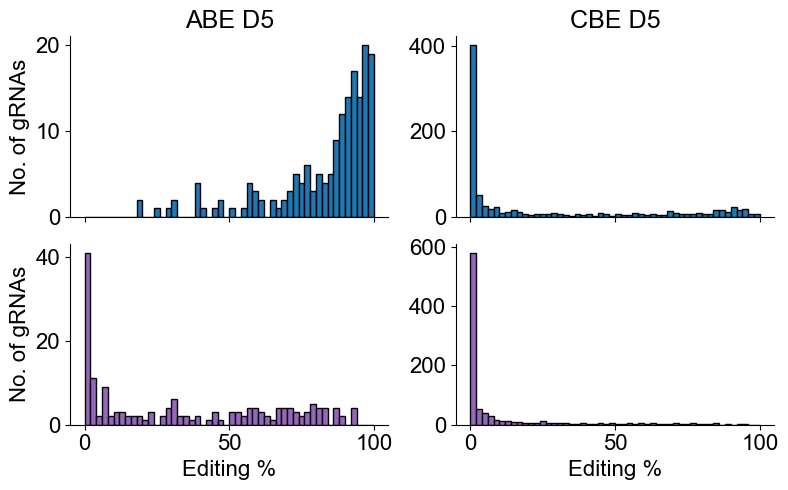

In [34]:
ABE_target_gudies = LIB[(LIB['Editor']=='ABE') & (LIB['classification']=='targeting guide')]
CBE_target_gudies = LIB[(LIB['Editor']=='CBE') & (LIB['classification'].isin(['targeting guide','essential truncation guide']))]

ABE_edits = pd.merge(d5_ABE, ABE_target_gudies, on='gRNA_id')
CBE_edits = pd.merge(d5_CBE, CBE_target_gudies, on='gRNA_id')

fig, ax = plt.subplots(2,2,figsize=(8,5), sharex=True, sharey=False)

ax[0][0].hist(ABE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:blue', edgecolor='black')
ax[1][0].hist(ABE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:purple', edgecolor='black')

ax[0][1].hist(CBE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), color='tab:blue', linewidth=1, edgecolor='black')
ax[1][1].hist(CBE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:purple', edgecolor='black')

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)
ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)
ax[0][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)
ax[1][0].set_xlabel('Editing %', fontsize=16)

ax[0][0].set_title('ABE D5', fontsize=18)
ax[0][1].set_title('CBE D5', fontsize=18)

fig.tight_layout()
# fig.savefig('figures/hist_d5_editing_perc.pdf')

# Evaluating correlation of editing efficiency 

## Correlation of editing efficiency D5, OG screen vs validation screen

- Subpool ABE and CBE
- Hex plot?

In [183]:
ABE_LFC = pd.read_csv('ABE_LFC_FDR_df.csv')
CBE_LFC = pd.read_csv('CBE_LFC_FDR_df.csv')
ABE_LFC_OG = pd.read_csv('ABE_LFC_FDR_df_og.csv')
CBE_LFC_OG = pd.read_csv('CBE_LFC_FDR_df_og.csv')

In [168]:
ABE_LFC['sensor_reads']

0       1932
1       8027
2      31597
3      13089
4      16805
       ...  
371        0
372        0
373        0
374        0
375        0
Name: sensor_reads, Length: 376, dtype: int64

In [169]:
df_ABE = ABE_LFC[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']]
df_ABE.columns = ['gRNA_id','corr_perc_validation','target_base_edit_perc_validation','sensor_reads_validation']
df_ABE_og = ABE_LFC_OG[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']]
ABE_edit_corr = pd.merge(df_ABE,df_ABE_og)
ABE_edit_corr = ABE_edit_corr[ABE_edit_corr['gRNA_id'].isin(ABE['gRNA_id'])].reset_index(drop=True)
ABE_edit_corr

,gRNA_id,corr_perc_validation,target_base_edit_perc_validation,sensor_reads_validation,corr_perc,target_base_edit_perc,sensor_reads
0,gRNA_2,13.354037,29.968944,1932,11.890244,17.682927,328
1,gRNA_85,13.442133,74.635605,8027,8.875740,56.804734,338
2,gRNA_871,0.363959,31.756179,31597,0.063877,19.131268,3131
3,gRNA_895,3.338681,91.489037,13089,3.386809,97.504456,561
4,gRNA_896,0.130913,51.270455,16805,0.000000,70.483871,1240
...,...,...,...,...,...,...,...
165,gRNA_12602,1.824797,31.476377,36278,1.165426,25.380382,3089
166,gRNA_12604,51.954057,95.443019,13408,47.963801,90.497738,1326
167,gRNA_12652,79.208496,90.138481,30979,90.594059,96.004243,2828
168,gRNA_12831,10.464548,96.218419,6135,9.426230,98.668033,976


In [171]:
df_CBE = CBE_LFC[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']]
df_CBE.columns = ['gRNA_id','corr_perc_validation','target_base_edit_perc_validation','sensor_reads_validation']
df_CBE_og = CBE_LFC_OG[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']]
CBE_edit_corr = pd.merge(df_CBE,df_CBE_og)
CBE_edit_corr = CBE_edit_corr[CBE_edit_corr['gRNA_id'].isin(CBE['gRNA_id'])].reset_index(drop=True)
CBE_edit_corr = CBE_edit_corr.dropna(subset='corr_perc').reset_index(drop=True)
CBE_edit_corr

,gRNA_id,corr_perc_validation,target_base_edit_perc_validation,sensor_reads_validation,corr_perc,target_base_edit_perc,sensor_reads
0,gRNA_4,3.078770,3.631920,23321,13.341969,28.691710,1544
1,gRNA_19,1.034969,82.337567,19131,20.192308,70.299145,936
2,gRNA_21,8.982036,29.241517,1002,0.043459,91.460235,4602
3,gRNA_289,1.948342,69.809634,22378,0.894569,20.638978,1565
4,gRNA_295,0.000000,0.000000,217,50.510204,61.224490,196
...,...,...,...,...,...,...,...
726,gRNA_14396,0.099985,96.768122,34005,9.270741,90.197815,3387
727,gRNA_14397,4.573805,47.401247,481,0.000000,11.585366,164
728,gRNA_14402,4.426076,92.083412,26615,46.520456,97.300717,2371
729,gRNA_14407,0.188690,1.032244,18019,0.065062,47.950553,1537


In [142]:
# ABE first
import scipy.stats  # Import scipy.stats to resolve the NameError

corr_spearman, p_value_spearman = scipy.stats.spearmanr(ABE_edit_corr['target_base_edit_perc'], ABE_edit_corr['target_base_edit_perc_validation'])

print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
print(p_value_spearman)

corr_pearson, p_value_pearson = scipy.stats.pearsonr(ABE_edit_corr['target_base_edit_perc'], ABE_edit_corr['target_base_edit_perc_validation'])

print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
print(p_value_pearson)

Spearman Correlation Coefficient: 0.7425
4.767142888025547e-31
Pearson Correlation Coefficient: 0.8544
1.2279265562203391e-49


In [143]:
# CBE
import scipy.stats  # Import scipy.stats to resolve the NameError

corr_spearman, p_value_spearman = scipy.stats.spearmanr(CBE_edit_corr['target_base_edit_perc'], CBE_edit_corr['target_base_edit_perc_validation'])

print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
print(p_value_spearman)

corr_pearson, p_value_pearson = scipy.stats.pearsonr(CBE_edit_corr['target_base_edit_perc'], CBE_edit_corr['target_base_edit_perc_validation'])

print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
print(p_value_pearson)

Spearman Correlation Coefficient: 0.3365
8.167021966238616e-21
Pearson Correlation Coefficient: 0.2902
1.1940359465144695e-15


ABE
Spearman Correlation Coefficient: 0.7425
4.767142888025547e-31
Pearson Correlation Coefficient: 0.8544
1.2279265562203391e-49
CBE
Spearman Correlation Coefficient: 0.3365
8.167021966238616e-21
Pearson Correlation Coefficient: 0.2902
1.1940359465144695e-15


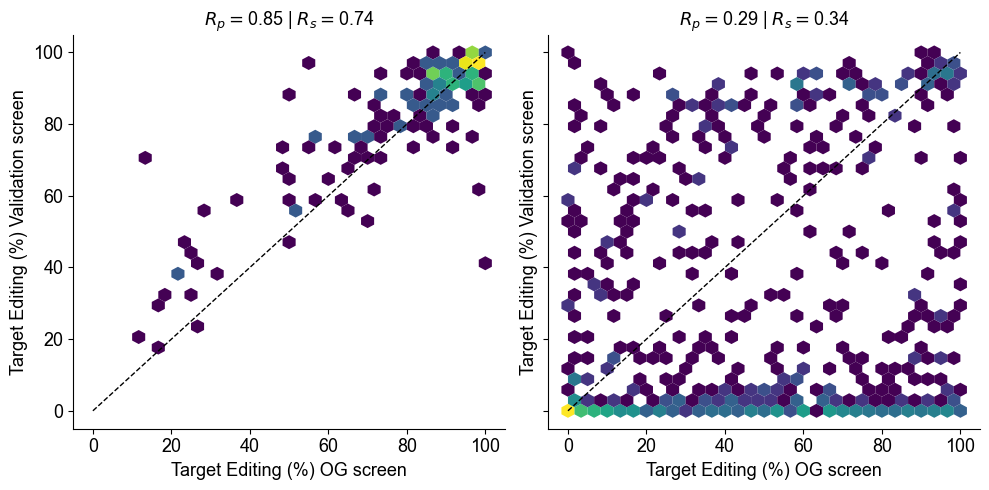

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (10,5), sharey=True)

for i, (df, name) in enumerate(zip([ABE_edit_corr, CBE_edit_corr], ['ABE','CBE'])):
    print(name)
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['target_base_edit_perc'], df['target_base_edit_perc_validation'])
    print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
    print(p_value_spearman)
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['target_base_edit_perc'], df['target_base_edit_perc_validation'])
    print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
    print(p_value_pearson)
    pear = "{:.2f}".format(corr_pearson)
    spear = "{:.2f}".format(corr_spearman)
    ax[i].hexbin(df['target_base_edit_perc'], df['target_base_edit_perc_validation'],  bins='log',gridsize=30, linewidth=0, color=[])
    ax[i].set_title('$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)
    ax[i].plot([0,100],[0,100], linestyle='dashed', color='black', linewidth=1)
    ax[i].set_xlabel('Target Editing (%) OG screen', fontsize=13)
    ax[i].set_ylabel('Target Editing (%) Validation screen', fontsize=13)
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=13,)

fig.tight_layout()
fig.savefig('figures/hex_editing_efficiency_og_vs_validation.pdf')

In [175]:
ABE_plot = ABE_edit_corr[ABE_edit_corr['sensor_reads']>=100].reset_index(drop=True)
CBE_plot = CBE_edit_corr[CBE_edit_corr['sensor_reads']>=100].reset_index(drop=True)

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (12,6), sharey=True)

for i, (df, name) in enumerate(zip([ABE_plot, CBE_plot], ['ABE','CBE'])):
    print(name)
    corr_spearman, p_value_spearman = scipy.stats.spearmanr(df['target_base_edit_perc'], df['target_base_edit_perc_validation'])
    print("Spearman Correlation Coefficient: {:.4f}".format(corr_spearman))
    print(p_value_spearman)
    corr_pearson, p_value_pearson = scipy.stats.pearsonr(df['target_base_edit_perc'], df['target_base_edit_perc_validation'])
    print("Pearson Correlation Coefficient: {:.4f}".format(corr_pearson))
    print(p_value_pearson)
    pear = "{:.2f}".format(corr_pearson)
    spear = "{:.2f}".format(corr_spearman)
    ax[i].hexbin(df['target_base_edit_perc'], df['target_base_edit_perc_validation'],  bins='log',gridsize=30, linewidth=0, extent = (0, 100, 0, 100))
    ax[i].set_title('$R_{p} = $' + f'{pear}' + ' | $R_{s} = $' + f'{spear}', fontsize=13)
    ax[i].plot([0,100],[0,100], linestyle='dashed', color='black', linewidth=1)
    ax[i].set_xlabel('Target Editing (%) OG screen', fontsize=13)
    ax[i].set_ylabel('Target Editing (%) Validation screen', fontsize=13)
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=13,)

fig.tight_layout()
fig.savefig('figures/hex_editing_efficiency_og_vs_validation_min_reads_100.pdf')

# Evaluate PAM bias of editing efficiency

In [240]:
LIB[['Protospacer','Protospacer_30']]

,Protospacer,Protospacer_30
0,GTTCTAAGGTGAAAAGCTCC,TTTTTTTCTAAGGTGAAAAGCTCCGGGTCT
1,GGCTCTGAGTTCCGGGAGAT,CATCTGCTCTGAGTTCCGGGAGATGGCAAG
2,GTGCTTCCTCGGAAAGAGCG,GCCACTGCTTCCTCGGAAAGAGCGCGGGCC
3,GGAGGCCGAACAAGAACGCA,TGCAGGAGGCCGAACAAGAACGCAGGAAGC
4,GAGGACAACGACTACGGCCG,GCTGGAGGACAACGACTACGGCCGTGCAGT
...,...,...
1628,GTCTTAACCAGCGCATCCCG,NaN
1629,GAGGCGGGCTCTTCTATCGT,NaN
1630,GCGCACCCATACAGGCGCTT,NaN
1631,GAACCGTGCGATGCGCGCTA,NaN


In [241]:
list_pre_proto, list_post_proto = [], []
for protospacer, protospacer_30 in zip(LIB['Protospacer'], LIB['Protospacer_30']):
    if not isinstance(protospacer, str):
        list_pre_proto.append(np.nan)
        list_post_proto.append(np.nan)
        continue
    else:
        if isinstance(protospacer_30, str):
            pre, post = protospacer_30.split(protospacer[1:], 1)
        else:
            pre, post = np.nan, np.nan
        list_pre_proto.append(pre)
        list_post_proto.append(post)

In [242]:
PAM_NGN = [x[:3] if isinstance(x, str) else np.nan for x in list_post_proto]
LIB['PAM_NGN'] = PAM_NGN

In [243]:
ABE_target_gudies = LIB[(LIB['Editor']=='ABE') & (LIB['classification']=='targeting guide')]
CBE_target_gudies = LIB[(LIB['Editor']=='CBE') & (LIB['classification'].isin(['targeting guide','essential truncation guide']))]

ABE_edits = pd.merge(d5_ABE, ABE_target_gudies, on='gRNA_id')
CBE_edits = pd.merge(d5_CBE, CBE_target_gudies, on='gRNA_id')

In [244]:
ABE_edits_filtered = ABE_edits[ABE_edits['Reads_in_input']>=100].reset_index(drop=True)
CBE_edits_filtered = CBE_edits[CBE_edits['Reads_in_input']>=100].reset_index(drop=True)

In [245]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

In [246]:
PAM_NGG = [f"{x}GG" for x in ['A','T','C','G']]
PAM_NGA = [f"{x}GA" for x in ['A','T','C','G']]
PAM_NGT = [f"{x}GT" for x in ['A','T','C','G']]
PAM_NGC = [f"{x}GC" for x in ['A','T','C','G']]

In [247]:
PAM_NGG

['AGG', 'TGG', 'CGG', 'GGG']

[48, 122]


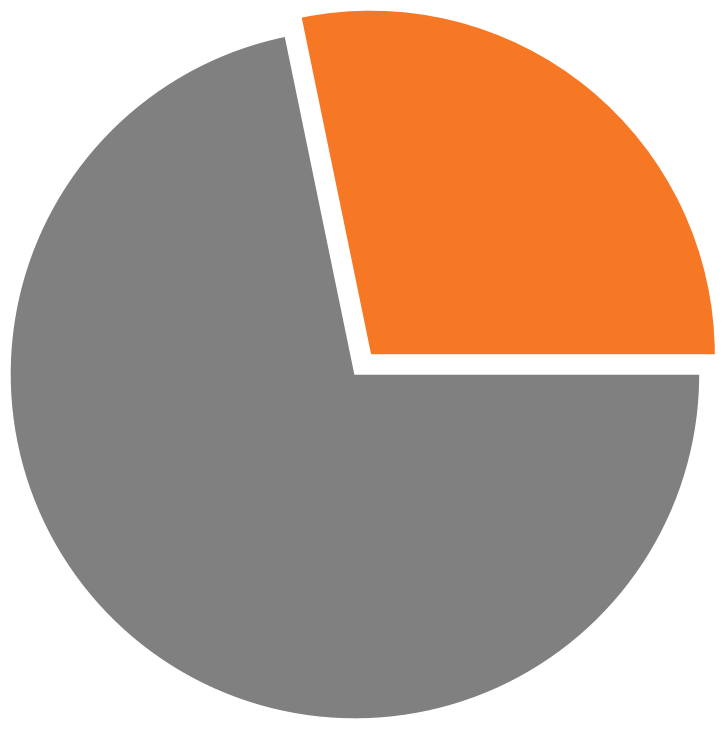

In [251]:
# a pie ploy showing the composition of the focused CBE library
NGG = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)

list_numbers = [len(NGG), len(NGN)]
print(list_numbers)

fig, ax = plt.subplots(figsize=(8, 8))
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
mypie, _ = ax.pie(list_numbers, radius = 1.4, colors = [yellows[3], 'gray'],
                  explode = (.1,0,))

plt.setp(mypie, edgecolor='white')
plt.savefig('figures/ABE_NG_pie.pdf', bbox_inches = 'tight', dpi=300)
plt.show()

[256, 565]


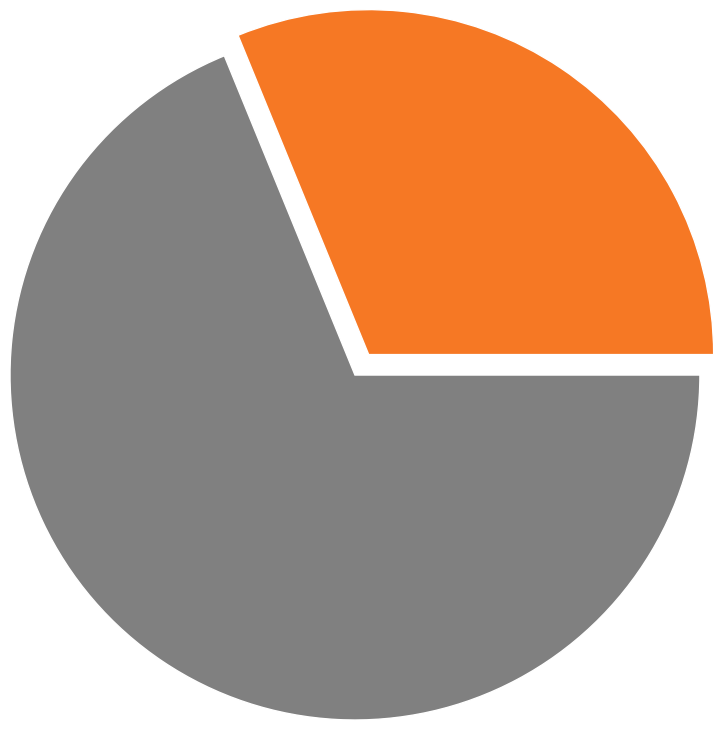

In [252]:
NGG = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)
list_numbers = [len(NGG), len(NGN)]
print(list_numbers)
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
mypie, _ = ax.pie(list_numbers, radius = 1.4, colors = [yellows[3], 'gray'],
                  explode = (.1,0,))

plt.setp(mypie, edgecolor='white')
plt.savefig('figures/CBE_NG_pie.pdf', bbox_inches = 'tight', dpi=300)
plt.show()

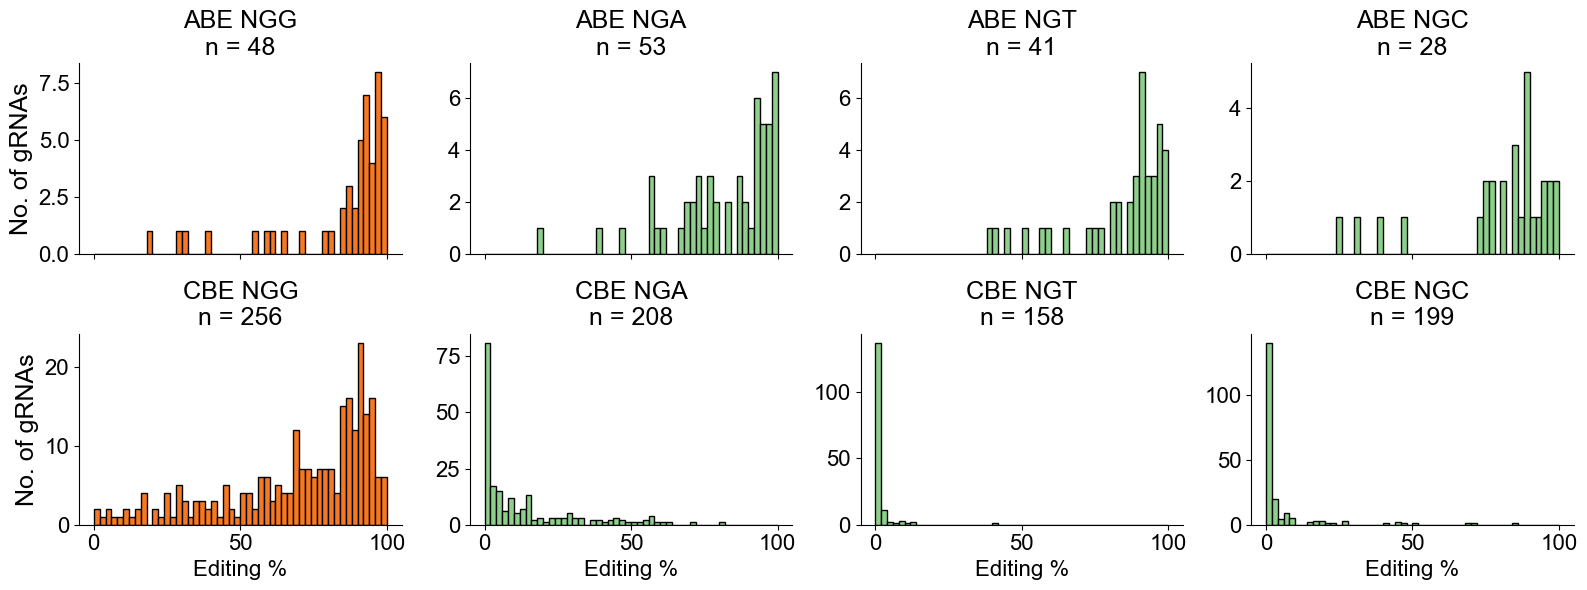

In [179]:
fig, ax = plt.subplots(2,4,figsize=(16,6), sharex=True, sharey=False)

NGG = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)

list_numbers = [len(NGG), len(NGA), len(NGT), len(NGC)]

ax[0][0].hist(NGG['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=yellows[3], edgecolor='black')
ax[0][1].hist(NGA['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[0][2].hist(NGT['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[0][3].hist(NGC['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')

ax[0][0].set_title('ABE NGG\nn = ' + str(list_numbers[0]), fontsize=18)
ax[0][1].set_title('ABE NGA\nn = ' + str(list_numbers[1]), fontsize=18)
ax[0][2].set_title('ABE NGT\nn = ' + str(list_numbers[2]), fontsize=18)
ax[0][3].set_title('ABE NGC\nn = ' + str(list_numbers[3]), fontsize=18)

NGG = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)

list_numbers = [len(NGG), len(NGA), len(NGT), len(NGC)]

ax[1][0].hist(NGG['target_base_edit_perc'], bins=np.linspace(0,100,51), color=yellows[3], linewidth=1, edgecolor='black')
ax[1][1].hist(NGA['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[1][2].hist(NGT['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[1][3].hist(NGC['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')

ax[1][0].set_title('CBE NGG\nn = ' + str(list_numbers[0]), fontsize=18)
ax[1][1].set_title('CBE NGA\nn = ' + str(list_numbers[1]), fontsize=18)
ax[1][2].set_title('CBE NGT\nn = ' + str(list_numbers[2]), fontsize=18)
ax[1][3].set_title('CBE NGC\nn = ' + str(list_numbers[3]), fontsize=18)

for x in range(2):
    for y in range(4):
        ax[x][y].spines[['top', 'right']].set_visible(False)
        ax[x][y].tick_params(axis='both', which='major', labelsize=16,)

ax[1][0].set_xlabel('Editing %', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)
ax[1][2].set_xlabel('Editing %', fontsize=16)
ax[1][3].set_xlabel('Editing %', fontsize=16)
ax[0][0].set_ylabel('No. of gRNAs', fontsize=18)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=18)

fig.tight_layout()
fig.savefig('figures/hist_d5_editing_PAM.pdf')


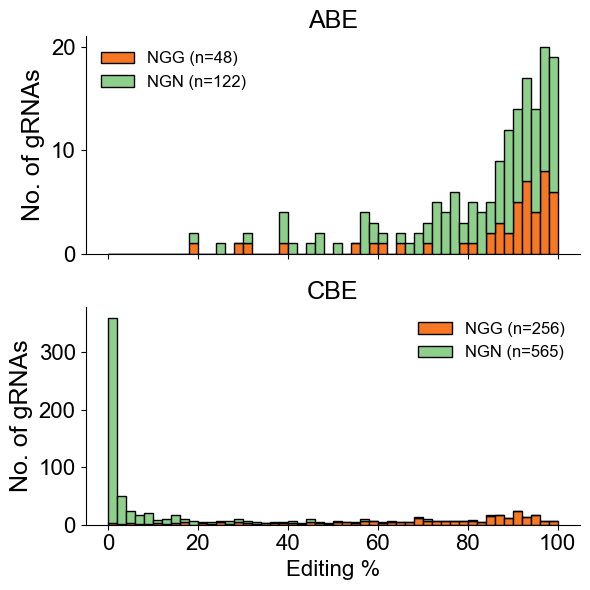

In [167]:
import numpy as np
import pandas as pd

bins = np.linspace(0, 100, 51)

fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True, sharey=False)

# ---------- ABE ----------
NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

# Stacked histogram: NGG (bottom) + NGN (top)
ax[0].hist(
    [NGG_abe['target_base_edit_perc'].to_numpy(),
     NGN_abe['target_base_edit_perc'].to_numpy()],
    bins=bins,
    stacked=True,
    edgecolor='black',
    linewidth=1,
    color=[yellows[3], greens[2]],
    label=[f"NGG (n={len(NGG_abe)})", f"NGN (n={len(NGN_abe)})"],
)

ax[0].set_title("ABE", fontsize=18)
ax[0].set_ylabel("No. of gRNAs", fontsize=18)
ax[0].legend(frameon=False, fontsize=12)

# ---------- CBE ----------
NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_cbe = pd.concat((NGA_cbe, NGT_cbe, NGC_cbe), ignore_index=True)

ax[1].hist(
    [NGG_cbe['target_base_edit_perc'].to_numpy(),
     NGN_cbe['target_base_edit_perc'].to_numpy()],
    bins=bins,
    stacked=True,
    edgecolor='black',
    linewidth=1,
    color=[yellows[3], greens[2]],
    label=[f"NGG (n={len(NGG_cbe)})", f"NGN (n={len(NGN_cbe)})"],
)

ax[1].set_title("CBE", fontsize=18)
ax[1].set_xlabel("Editing %", fontsize=16)
ax[1].set_ylabel("No. of gRNAs", fontsize=18)
ax[1].legend(frameon=False, fontsize=12)

# ---------- styling ----------
for i in range(2):
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=16)

fig.tight_layout()
fig.savefig("figures/hist_d5_editing_PAM_NGG_vs_NGN_stacked.pdf")


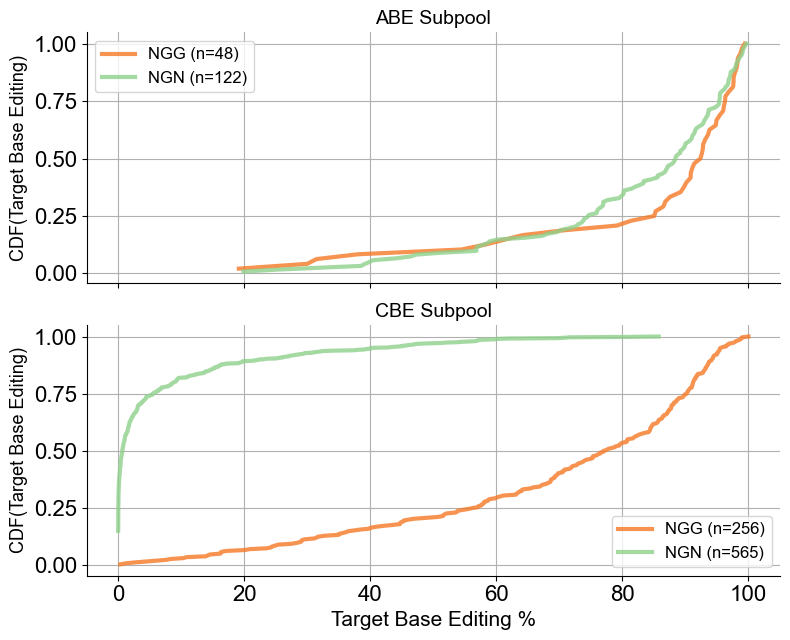

In [178]:
fig, ax = plt.subplots(2,1,figsize=(8,6.5), sharex=True)

NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

x,y = ecdf(NGG_abe['target_base_edit_perc'])
ax[0].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_abe)})')
x1,y1 = ecdf(NGN_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=greens[2], alpha=.8, label=f'NGN (n={len(NGN_abe)})')

NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
x,y = ecdf(NGG_cbe['target_base_edit_perc'])
ax[1].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_cbe)})')
x1,y1 = ecdf(NGN_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=greens[2], alpha=.8, label=f'NGN (n={len(NGN_cbe)})')


ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='upper left')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_xlabel('Target Base Editing %', fontsize=15)

ax[0].set_title('ABE Subpool', fontsize=14)
ax[1].set_title('CBE Subpool', fontsize=14)
ax[1].grid()
ax[0].grid()
ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='lower right')
fig.tight_layout()
fig.savefig('figures/cdf_PAM_NGN.pdf')

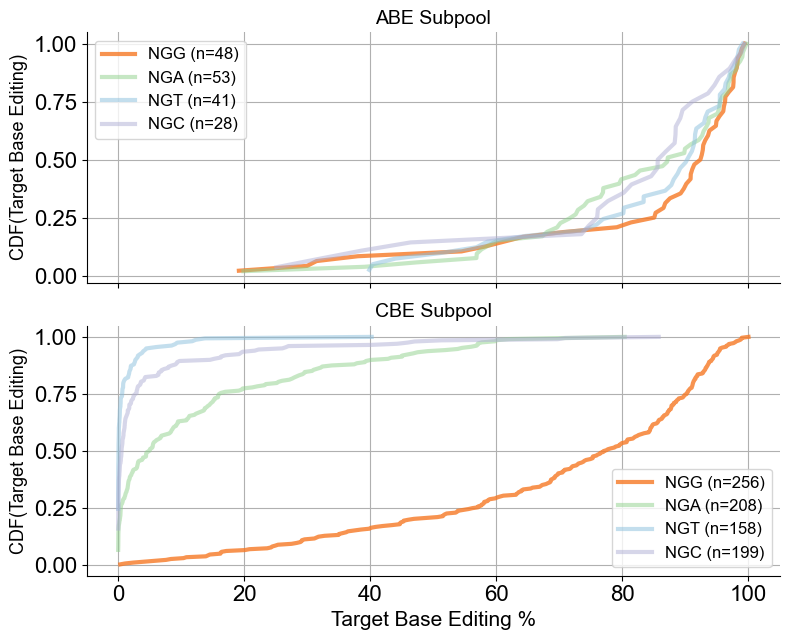

In [177]:
fig, ax = plt.subplots(2,1,figsize=(8,6.5), sharex=True)

NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

x,y = ecdf(NGG_abe['target_base_edit_perc'])
ax[0].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_abe)})')
x1,y1 = ecdf(NGA_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=greens[2], alpha=.5, label=f'NGA (n={len(NGA_abe)})')
x1,y1 = ecdf(NGT_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=blues[2], alpha=.5, label=f'NGT (n={len(NGT_abe)})')
x1,y1 = ecdf(NGC_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=purples[2], alpha=.5, label=f'NGC (n={len(NGC_abe)})')

NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)

x,y = ecdf(NGG_cbe['target_base_edit_perc'])
ax[1].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_cbe)})')
x1,y1 = ecdf(NGA_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=greens[2], alpha=.5, label=f'NGA (n={len(NGA_cbe)})')
x1,y1 = ecdf(NGT_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=blues[2], alpha=.5, label=f'NGT (n={len(NGT_cbe)})')
x1,y1 = ecdf(NGC_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=purples[2], alpha=.5, label=f'NGC (n={len(NGC_cbe)})')


ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='upper left')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_xlabel('Target Base Editing %', fontsize=15)

ax[0].set_title('ABE Subpool', fontsize=14)
ax[1].set_title('CBE Subpool', fontsize=14)
ax[1].grid()
ax[0].grid()
ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='lower right')
fig.tight_layout()
fig.savefig('figures/cdf_PAM_NGN_separate.pdf')

# Evaluate PAM bias of editing efficiency - OG screen

In [186]:
LIB_OG = pd.read_csv('MBESv2_corrected.csv')
ABE_OG = LIB_OG[(LIB_OG['Editor']=='ABE') & (LIB_OG['classification']=='targeting guide')]
#CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['legacy']==False) & (MBES['classification']=='targeting guide')]
CBE_OG = LIB_OG[(LIB_OG['Editor']=='CBE') & (LIB_OG['classification']=='targeting guide')]

In [187]:
ABE_LFC_OG = pd.read_csv('ABE_LFC_FDR_df_og.csv')
CBE_LFC_OG = pd.read_csv('CBE_LFC_FDR_df_og.csv')

# Evaluate PAM bias of editing efficiency

In [188]:
LIB_OG[['Protospacer','Protospacer_30']]

,Protospacer,Protospacer_30
0,GTCTAAGGTGAAAAGCTCCG,TTTTTTCTAAGGTGAAAAGCTCCGGGTCTT
1,GTTCTAAGGTGAAAAGCTCC,TTTTTTTCTAAGGTGAAAAGCTCCGGGTCT
2,GTTTCTAAGGTGAAAAGCTC,TTTTTTTTCTAAGGTGAAAAGCTCCGGGTC
3,GGCTCTGAGTTCCGGGAGAT,CATCTGCTCTGAGTTCCGGGAGATGGCAAG
4,GTGCTCTGAGTTCCGGGAGA,CCATCTGCTCTGAGTTCCGGGAGATGGCAA
...,...,...
14407,GTTCTCACTCTCATACCCTG,NaN
14408,GACACACCCACGGGGTCTTC,NaN
14409,GACACCCACGGGGTCTTCCG,NaN
14410,GCACCCACGGGGTCTTCCGA,NaN


In [190]:
list_pre_proto, list_post_proto = [], []
for protospacer, protospacer_30 in zip(LIB_OG['Protospacer'], LIB_OG['Protospacer_30']):
    if not isinstance(protospacer, str):
        list_pre_proto.append(np.nan)
        list_post_proto.append(np.nan)
        continue
    else:
        if isinstance(protospacer_30, str):
            pre, post = protospacer_30.split(protospacer[1:], 1)
        else:
            pre, post = np.nan, np.nan
        list_pre_proto.append(pre)
        list_post_proto.append(post)

In [209]:
PAM_NGN = [x[:3] if isinstance(x, str) else np.nan for x in list_post_proto]
LIB_OG['PAM_NGN'] = PAM_NGN

In [210]:
ABE_target_gudies = LIB_OG[(LIB_OG['Editor']=='ABE') & (LIB_OG['classification']=='targeting guide')]
CBE_target_gudies = LIB_OG[(LIB_OG['Editor']=='CBE') & (LIB_OG['classification'].isin(['targeting guide','essential truncation guide']))]

In [216]:
ABE_edits = pd.merge(ABE_LFC_OG[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']], ABE_target_gudies, on='gRNA_id')
CBE_edits = pd.merge(CBE_LFC_OG[['gRNA_id','corr_perc','target_base_edit_perc','sensor_reads']], CBE_target_gudies, on='gRNA_id')

In [224]:
ABE_edits_filtered = ABE_edits[ABE_edits['sensor_reads']>=10].reset_index(drop=True)
CBE_edits_filtered = CBE_edits[CBE_edits['sensor_reads']>=10].reset_index(drop=True)

In [225]:
PAM_NGG = [f"{x}GG" for x in ['A','T','C','G']]
PAM_NGA = [f"{x}GA" for x in ['A','T','C','G']]
PAM_NGT = [f"{x}GT" for x in ['A','T','C','G']]
PAM_NGC = [f"{x}GC" for x in ['A','T','C','G']]

In [226]:
PAM_NGG

['AGG', 'TGG', 'CGG', 'GGG']

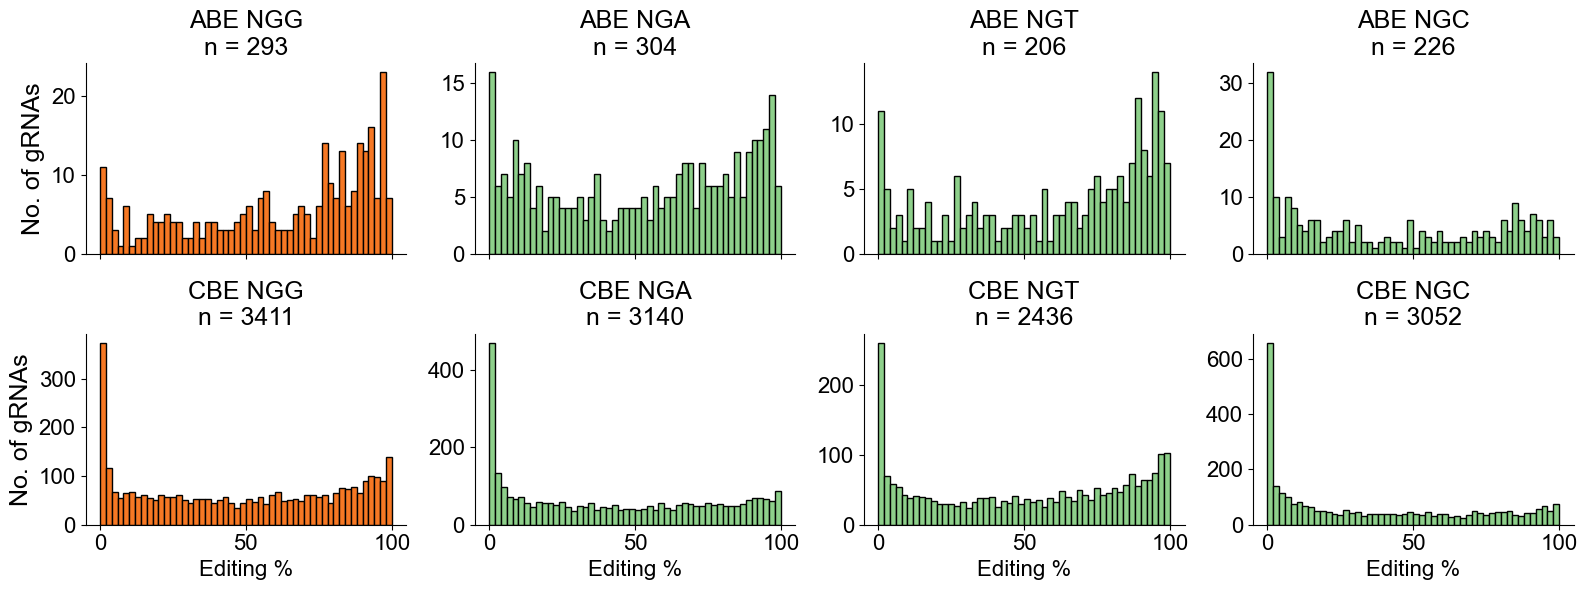

In [227]:
fig, ax = plt.subplots(2,4,figsize=(16,6), sharex=True, sharey=False)

NGG = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)

list_numbers = [len(NGG), len(NGA), len(NGT), len(NGC)]

ax[0][0].hist(NGG['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=yellows[3], edgecolor='black')
ax[0][1].hist(NGA['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[0][2].hist(NGT['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[0][3].hist(NGC['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')

ax[0][0].set_title('ABE NGG\nn = ' + str(list_numbers[0]), fontsize=18)
ax[0][1].set_title('ABE NGA\nn = ' + str(list_numbers[1]), fontsize=18)
ax[0][2].set_title('ABE NGT\nn = ' + str(list_numbers[2]), fontsize=18)
ax[0][3].set_title('ABE NGC\nn = ' + str(list_numbers[3]), fontsize=18)

NGG = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN = pd.concat((NGA, NGT, NGC)).reset_index(drop=True)

list_numbers = [len(NGG), len(NGA), len(NGT), len(NGC)]

ax[1][0].hist(NGG['target_base_edit_perc'], bins=np.linspace(0,100,51), color=yellows[3], linewidth=1, edgecolor='black')
ax[1][1].hist(NGA['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[1][2].hist(NGT['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')
ax[1][3].hist(NGC['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=greens[2], edgecolor='black')

ax[1][0].set_title('CBE NGG\nn = ' + str(list_numbers[0]), fontsize=18)
ax[1][1].set_title('CBE NGA\nn = ' + str(list_numbers[1]), fontsize=18)
ax[1][2].set_title('CBE NGT\nn = ' + str(list_numbers[2]), fontsize=18)
ax[1][3].set_title('CBE NGC\nn = ' + str(list_numbers[3]), fontsize=18)

for x in range(2):
    for y in range(4):
        ax[x][y].spines[['top', 'right']].set_visible(False)
        ax[x][y].tick_params(axis='both', which='major', labelsize=16,)

ax[1][0].set_xlabel('Editing %', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)
ax[1][2].set_xlabel('Editing %', fontsize=16)
ax[1][3].set_xlabel('Editing %', fontsize=16)
ax[0][0].set_ylabel('No. of gRNAs', fontsize=18)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=18)

fig.tight_layout()
fig.savefig('figures/OG_hist_d5_editing_PAM.pdf')


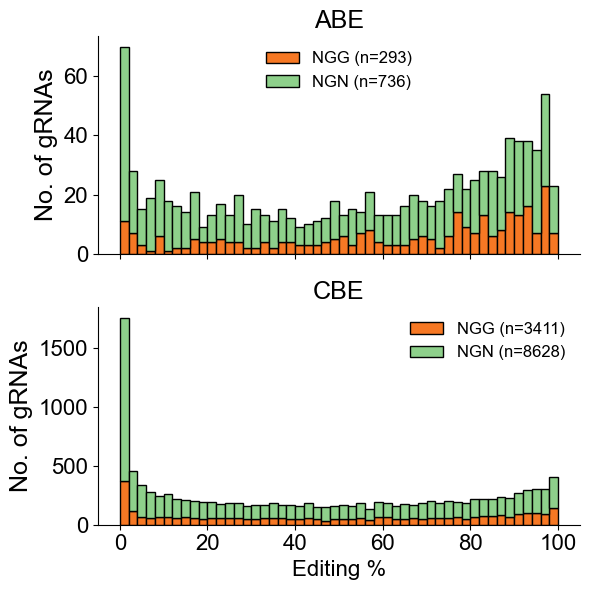

In [228]:
import numpy as np
import pandas as pd

bins = np.linspace(0, 100, 51)

fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True, sharey=False)

# ---------- ABE ----------
NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

# Stacked histogram: NGG (bottom) + NGN (top)
ax[0].hist(
    [NGG_abe['target_base_edit_perc'].to_numpy(),
     NGN_abe['target_base_edit_perc'].to_numpy()],
    bins=bins,
    stacked=True,
    edgecolor='black',
    linewidth=1,
    color=[yellows[3], greens[2]],
    label=[f"NGG (n={len(NGG_abe)})", f"NGN (n={len(NGN_abe)})"],
)

ax[0].set_title("ABE", fontsize=18)
ax[0].set_ylabel("No. of gRNAs", fontsize=18)
ax[0].legend(frameon=False, fontsize=12)

# ---------- CBE ----------
NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_cbe = pd.concat((NGA_cbe, NGT_cbe, NGC_cbe), ignore_index=True)

ax[1].hist(
    [NGG_cbe['target_base_edit_perc'].to_numpy(),
     NGN_cbe['target_base_edit_perc'].to_numpy()],
    bins=bins,
    stacked=True,
    edgecolor='black',
    linewidth=1,
    color=[yellows[3], greens[2]],
    label=[f"NGG (n={len(NGG_cbe)})", f"NGN (n={len(NGN_cbe)})"],
)

ax[1].set_title("CBE", fontsize=18)
ax[1].set_xlabel("Editing %", fontsize=16)
ax[1].set_ylabel("No. of gRNAs", fontsize=18)
ax[1].legend(frameon=False, fontsize=12)

# ---------- styling ----------
for i in range(2):
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=16)

fig.tight_layout()
fig.savefig("figures/OG_hist_d5_editing_PAM_NGG_vs_NGN_stacked.pdf")

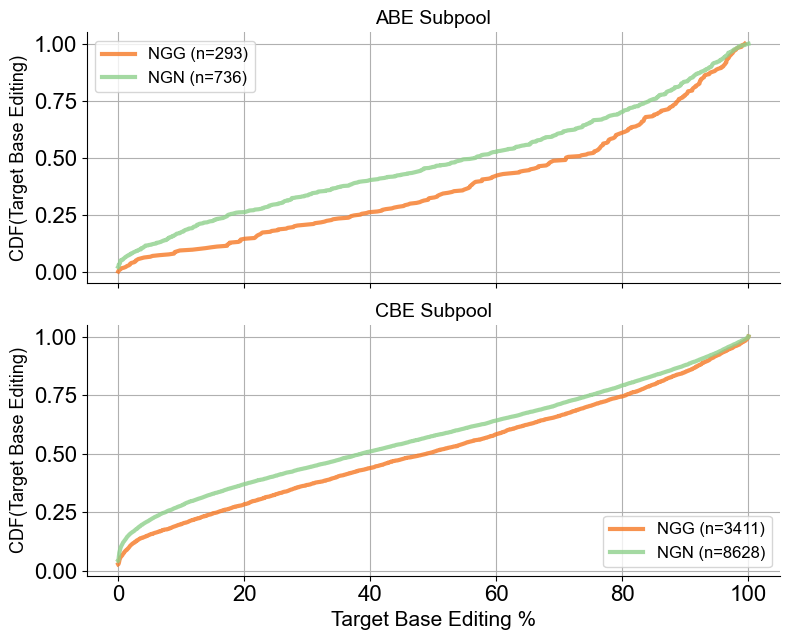

In [229]:
fig, ax = plt.subplots(2,1,figsize=(8,6.5), sharex=True)

NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

x,y = ecdf(NGG_abe['target_base_edit_perc'])
ax[0].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_abe)})')
x1,y1 = ecdf(NGN_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=greens[2], alpha=.8, label=f'NGN (n={len(NGN_abe)})')

NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
x,y = ecdf(NGG_cbe['target_base_edit_perc'])
ax[1].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_cbe)})')
x1,y1 = ecdf(NGN_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=greens[2], alpha=.8, label=f'NGN (n={len(NGN_cbe)})')


ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='upper left')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_xlabel('Target Base Editing %', fontsize=15)

ax[0].set_title('ABE Subpool', fontsize=14)
ax[1].set_title('CBE Subpool', fontsize=14)
ax[1].grid()
ax[0].grid()
ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='lower right')
fig.tight_layout()
fig.savefig('figures/OG_cdf_PAM_NGN.pdf')

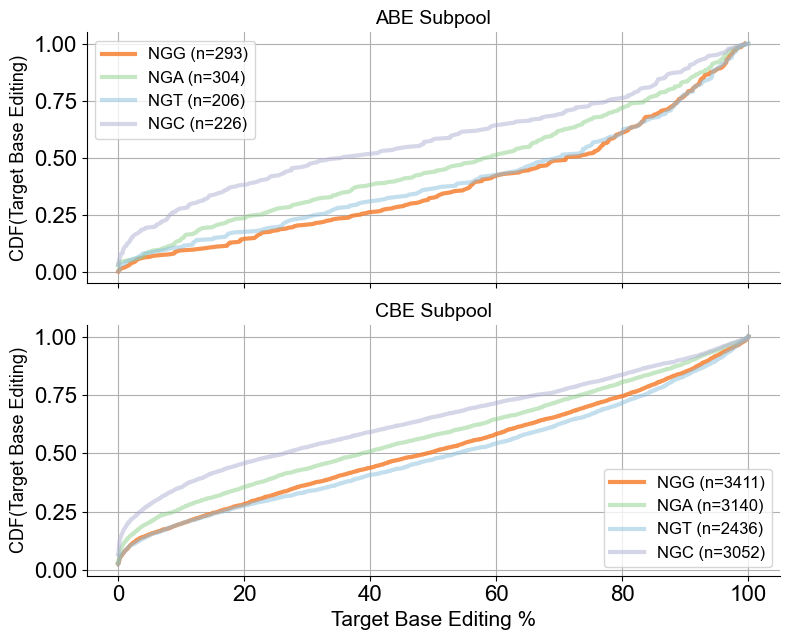

In [230]:
fig, ax = plt.subplots(2,1,figsize=(8,6.5), sharex=True)

NGG_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_abe = ABE_edits_filtered[ABE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)
NGN_abe = pd.concat((NGA_abe, NGT_abe, NGC_abe), ignore_index=True)

x,y = ecdf(NGG_abe['target_base_edit_perc'])
ax[0].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_abe)})')
x1,y1 = ecdf(NGA_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=greens[2], alpha=.5, label=f'NGA (n={len(NGA_abe)})')
x1,y1 = ecdf(NGT_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=blues[2], alpha=.5, label=f'NGT (n={len(NGT_abe)})')
x1,y1 = ecdf(NGC_abe['target_base_edit_perc'])
ax[0].plot(x1,y1, linewidth=3, c=purples[2], alpha=.5, label=f'NGC (n={len(NGC_abe)})')

NGG_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
NGA_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGA)].reset_index(drop=True)
NGT_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGT)].reset_index(drop=True)
NGC_cbe = CBE_edits_filtered[CBE_edits_filtered['PAM_NGN'].isin(PAM_NGC)].reset_index(drop=True)

x,y = ecdf(NGG_cbe['target_base_edit_perc'])
ax[1].plot(x,y, linewidth=3, c=yellows[3], alpha=.8, label=f'NGG (n={len(NGG_cbe)})')
x1,y1 = ecdf(NGA_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=greens[2], alpha=.5, label=f'NGA (n={len(NGA_cbe)})')
x1,y1 = ecdf(NGT_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=blues[2], alpha=.5, label=f'NGT (n={len(NGT_cbe)})')
x1,y1 = ecdf(NGC_cbe['target_base_edit_perc'])
ax[1].plot(x1,y1, linewidth=3, c=purples[2], alpha=.5, label=f'NGC (n={len(NGC_cbe)})')


ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='upper left')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_ylabel('CDF(Target Base Editing)', fontsize=13)
ax[1].set_xlabel('Target Base Editing %', fontsize=15)

ax[0].set_title('ABE Subpool', fontsize=14)
ax[1].set_title('CBE Subpool', fontsize=14)
ax[1].grid()
ax[0].grid()
ax[0].legend(fontsize=12, loc='upper left')
ax[1].legend(fontsize=12, loc='lower right')
fig.tight_layout()
fig.savefig('figures/OG_cdf_PAM_NGN_separate.pdf')

In [232]:
LIB_OG['PAM_NGN']

0        GGT
1        GGG
2        CGG
3        GGC
4        TGG
        ... 
14407    NaN
14408    NaN
14409    NaN
14410    NaN
14411    NaN
Name: PAM_NGN, Length: 14412, dtype: object

In [239]:
LIB.to_csv('FINAL_focused_library_PAM.csv')
LIB_OG.to_csv('MBESv2_CORRECTED_PAM.csv')